In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [52]:
log_prob_matrix_d = np.load('log_prob.npy')

In [53]:
log_prob_matrix_d.shape

(100, 5000)

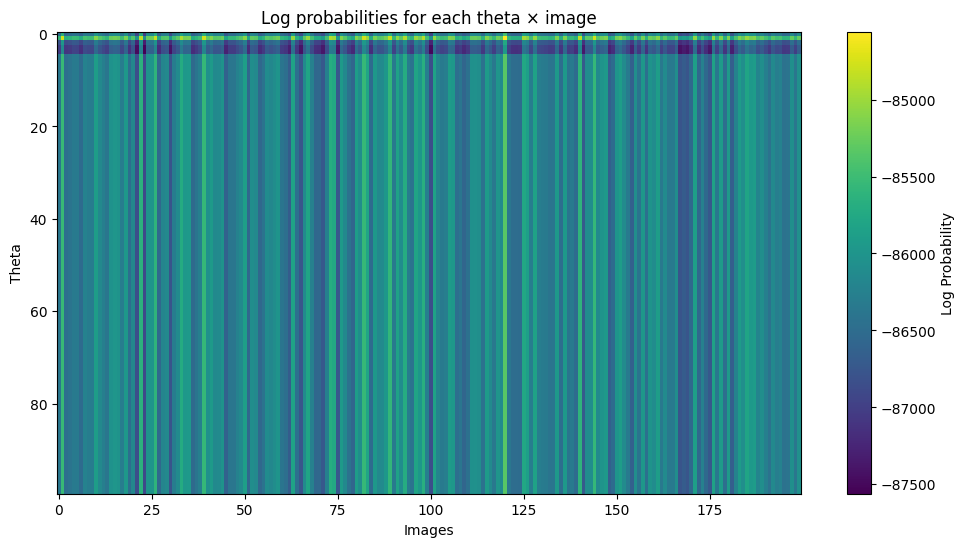

In [54]:
plt.figure(figsize=(12, 6))
plt.imshow(log_prob_matrix_d[:200,:200], aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()

In [55]:
# GENERAL PARAMETERS
# number of models
nframes=100#121
# number of maps
nmaps=5000 #3255453

In [56]:
# Objective function
def F(X):
    s = P.T @ X  # shape (M,)
    return -np.sum(np.log(s))

# Gradient
def grad_F(X):
    s = P.T @ X  # shape (M,)

    return -P @ (1.0 / s)  # shape (N,)

# minimizer
class ProjectedGradientDescentSimplex:
    def __init__(self, func, grad, n_vars, max_iters=10000, tol=1e-9):
        """
        func: callable f(x) -> float
        grad: callable grad_f(x) -> np.ndarray
        n_vars: number of variables
        max_iters: maximum iterations
        tol: tolerance for convergence
        """
        self.func = func
        self.grad = grad
        self.n_vars = n_vars
        self.max_iters = max_iters
        self.tol = tol
        self.history = []  # store f(x) values

    def project_to_simplex(self, v):
        """ Project v onto the unit simplex {x | sum(x)=1, x>=0} """
        n = len(v)
        u = np.sort(v)[::-1]
        cssv = np.cumsum(u)
        rho = np.nonzero(u * np.arange(1, n+1) > (cssv - 1))[0][-1]
        
        theta = (cssv[rho] - 1.0) / (rho + 1)
        return np.maximum(v - theta, 0.0)


    def minimize(self, x0=None):
        # Initialize
        if x0 is None:
            x = np.random.rand(self.n_vars)
        else:
            x = np.array(x0, dtype=np.float64)
        x = self.project_to_simplex(x)
        print(x)

        self.history = [self.func(x)]

        for i in range(self.max_iters):
            grad = self.grad(x)
            f_val = self.func(x)
            

            # Backtracking line search
            step = 1.0
            while True:
                x_new = self.project_to_simplex(x - step * grad)
                
                
                if self.func(x_new) <= f_val - 1e-4 * step * np.dot(grad, x - x_new):
                    break
                step *= 0.5
                if step < 1e-12:
                    break

            self.history.append(self.func(x_new))

            # Convergence check
            if np.linalg.norm(x_new - x) < self.tol:
                print(f"Converged in {i} iterations")
                return x_new

            x = x_new

        print("Reached maximum iterations")
        return x

    def plot_convergence(self):
        plt.figure(figsize=(6,4))
        plt.plot(self.history, marker='o')
        plt.xlabel("Iteration")
        plt.ylabel("f(x)")
        plt.title("Convergence of Projected Gradient Descent")
        plt.grid(True)
        plt.show()

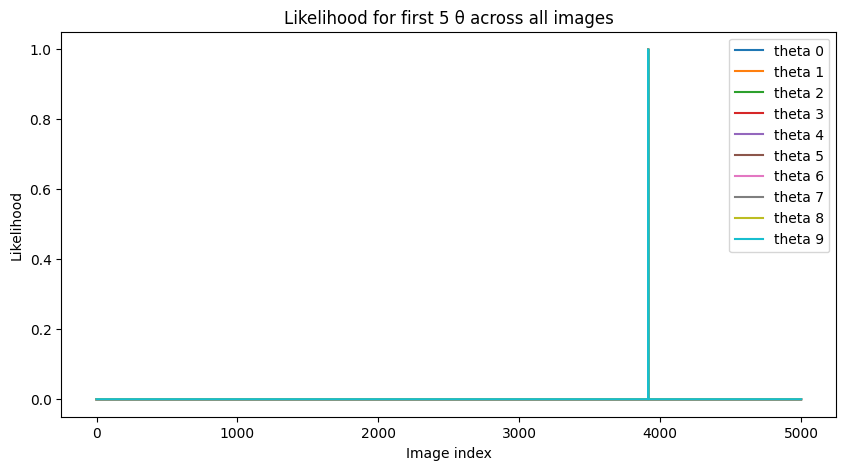

In [65]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.plot(np.exp(log_prob_matrix_d[i] - np.max(log_prob_matrix_d[i])), label=f"theta {i}")
plt.xlabel("Image index")
plt.ylabel("Likelihood")
plt.title("Likelihood for first 5 θ across all images")
plt.legend()
plt.show()


In [66]:
# create probability array
P = np.array(log_prob_matrix_d, dtype=np.float64)
# get maximum value
m = np.max(P)
# get likelihood probability matrix Nmodels*Nimages
P = np.exp(P-m)
# convert Nan or weird values into zero
#P = np.nan_to_num(P, nan=0.0, posinf=0.0, neginf=0.0)
# Make initial random weight vector the size of the number of nframes-1
w_i = np.random.random(nframes-1)
# sort values and insert 0 and 1
w_t = np.append(np.insert(np.sort(w_i), 0, 0.0), 1.0)
# Prepare weight array
X0 = np.zeros(nframes, dtype=np.float64)
# Loop through frames & subtract value n from value n+1
for b in range(nframes):
    X0[b] = w_t[b+1] - w_t[b]

In [67]:
print("X0:", X0)
print("Sum:", np.sum(X0))
print("Min:", np.min(X0))


X0: [2.88102355e-03 2.25166527e-02 1.12666088e-02 1.91996390e-03
 7.32229149e-04 3.62360290e-03 8.92547364e-04 5.13551905e-03
 1.29484474e-02 5.26869244e-04 3.78432850e-02 8.95201100e-03
 1.40344035e-02 2.75028273e-04 6.74466354e-03 2.01138199e-03
 2.28400126e-02 6.51298661e-03 5.25051524e-04 2.37980281e-02
 6.61909841e-03 4.98212377e-04 1.18412924e-02 7.95315616e-04
 1.47023706e-03 2.11056176e-03 2.64678423e-02 1.57978593e-02
 3.07879318e-02 1.59105429e-02 3.37387746e-02 8.29256368e-04
 3.71245805e-03 1.37556947e-03 5.09915865e-03 2.52126024e-04
 2.59478098e-02 9.85508712e-03 3.45191884e-03 5.58170916e-03
 3.58624825e-03 4.50101961e-03 8.92841470e-03 3.19059837e-02
 4.49251797e-03 7.94196714e-04 5.40983131e-03 8.00614386e-03
 1.71059753e-03 1.09974198e-05 4.17750145e-03 2.14978954e-02
 1.60946074e-03 1.44992250e-02 3.41709529e-02 2.35547650e-03
 5.29383857e-03 1.85965066e-03 2.19852846e-02 7.96696624e-04
 1.35612370e-02 1.08638535e-02 2.89933275e-02 2.31177219e-02
 1.57289080e-03 5.11

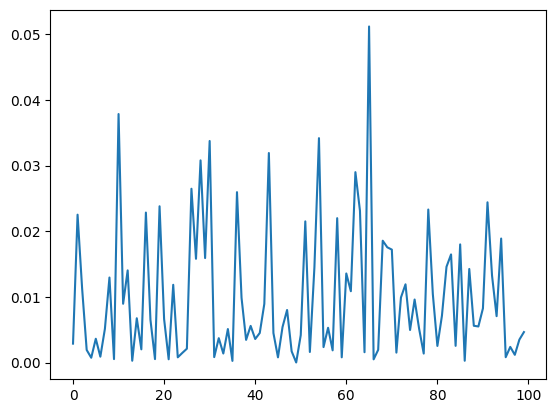

In [68]:
plt.plot(X0)

In [69]:
X0

array([2.88102355e-03, 2.25166527e-02, 1.12666088e-02, 1.91996390e-03,
       7.32229149e-04, 3.62360290e-03, 8.92547364e-04, 5.13551905e-03,
       1.29484474e-02, 5.26869244e-04, 3.78432850e-02, 8.95201100e-03,
       1.40344035e-02, 2.75028273e-04, 6.74466354e-03, 2.01138199e-03,
       2.28400126e-02, 6.51298661e-03, 5.25051524e-04, 2.37980281e-02,
       6.61909841e-03, 4.98212377e-04, 1.18412924e-02, 7.95315616e-04,
       1.47023706e-03, 2.11056176e-03, 2.64678423e-02, 1.57978593e-02,
       3.07879318e-02, 1.59105429e-02, 3.37387746e-02, 8.29256368e-04,
       3.71245805e-03, 1.37556947e-03, 5.09915865e-03, 2.52126024e-04,
       2.59478098e-02, 9.85508712e-03, 3.45191884e-03, 5.58170916e-03,
       3.58624825e-03, 4.50101961e-03, 8.92841470e-03, 3.19059837e-02,
       4.49251797e-03, 7.94196714e-04, 5.40983131e-03, 8.00614386e-03,
       1.71059753e-03, 1.09974198e-05, 4.17750145e-03, 2.14978954e-02,
       1.60946074e-03, 1.44992250e-02, 3.41709529e-02, 2.35547650e-03,
      

In [63]:
# run minimization
pgd = ProjectedGradientDescentSimplex(func=F, grad=grad_F, n_vars=nframes)
x_opt = pgd.minimize(X0)

print("Optimal x:", x_opt)
print("Sum of x:", np.sum(x_opt))
print("Minimum f(x):", F(x_opt))




[2.72665269e-03 3.36167174e-03 1.14516258e-02 2.93382079e-03
 2.29000305e-02 7.90102566e-03 1.21215714e-03 1.00221857e-02
 1.10913017e-02 1.28412797e-02 1.18890081e-03 4.73947267e-03
 2.59092211e-02 1.70358257e-02 1.54547251e-02 2.10488771e-02
 2.97052071e-03 2.59213518e-02 1.44270254e-02 1.24010181e-03
 1.58019045e-03 1.46420302e-02 2.24810317e-02 3.64778206e-03
 8.89275316e-04 1.47280603e-03 2.52062338e-02 4.22155617e-03
 5.46114522e-03 2.16220174e-03 4.59851700e-04 1.53020319e-02
 1.55864158e-03 3.08443513e-04 4.58155737e-03 3.20453470e-02
 2.05821872e-02 3.36497840e-03 1.99410373e-02 7.03834827e-03
 1.52329359e-02 3.17042034e-04 1.26573199e-03 4.11283358e-04
 2.37715035e-02 6.73335455e-03 1.49300730e-02 9.80970159e-03
 7.92582679e-03 1.17773271e-02 2.40833081e-02 9.55021664e-03
 5.62716187e-03 5.10655967e-03 2.17159407e-03 1.55950832e-02
 1.25483488e-02 1.29548938e-02 1.23426248e-02 2.62536275e-03
 1.42544684e-02 9.44172215e-04 2.41843325e-02 2.34631075e-02
 9.11670348e-03 2.694262

/tmp/ipykernel_1180973/1672528820.py:4: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(s))
/tmp/ipykernel_1180973/1672528820.py:10: RuntimeWarning: divide by zero encountered in divide
  return -P @ (1.0 / s)  # shape (N,)
/tmp/ipykernel_1180973/1672528820.py:10: RuntimeWarning: overflow encountered in divide
  return -P @ (1.0 / s)  # shape (N,)
/tmp/ipykernel_1180973/1672528820.py:10: RuntimeWarning: invalid value encountered in matmul
  return -P @ (1.0 / s)  # shape (N,)


IndexError: index -1 is out of bounds for axis 0 with size 0

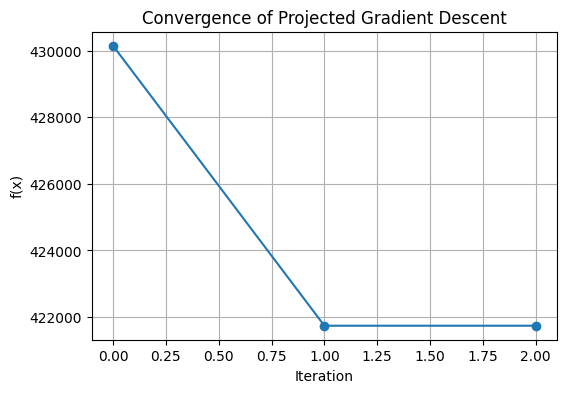

In [47]:
# Plot convergence
pgd.plot_convergence()

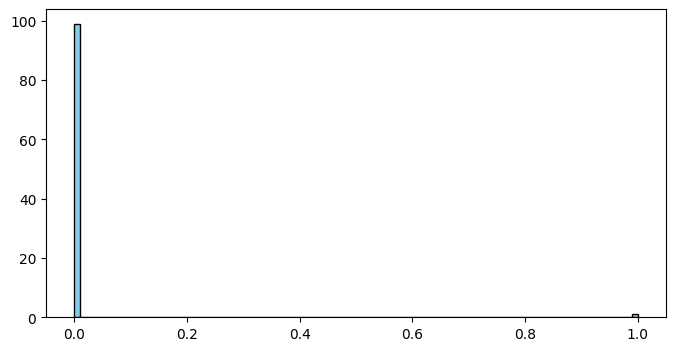

In [48]:
plt.figure(figsize=(8,4))
plt.hist(x_opt, bins=100, color='skyblue', edgecolor='black')
plt.show()

In [49]:
x_opt.shape


(100,)

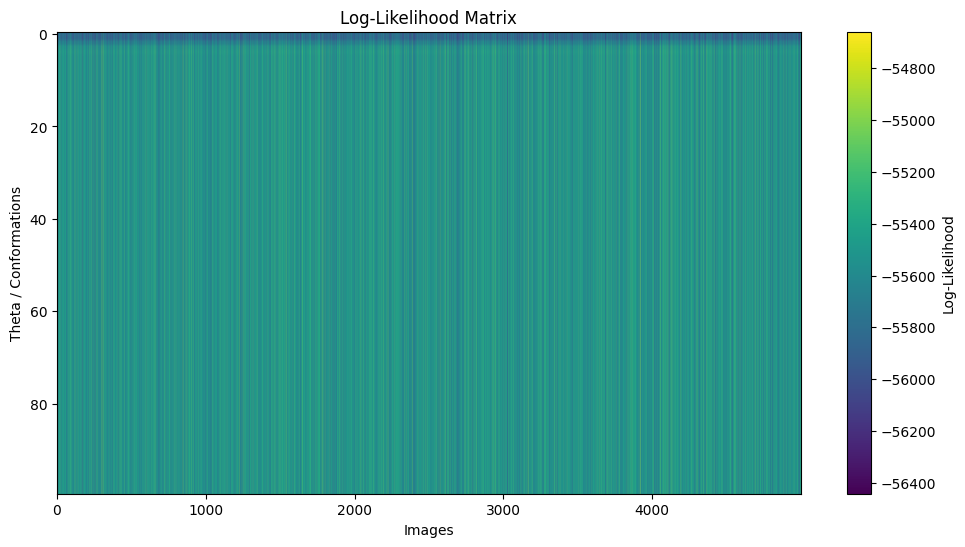

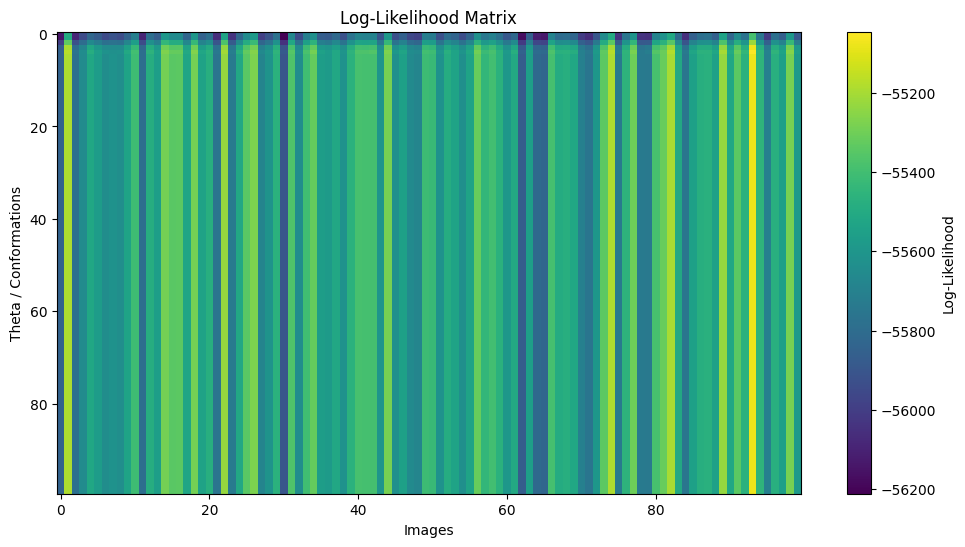

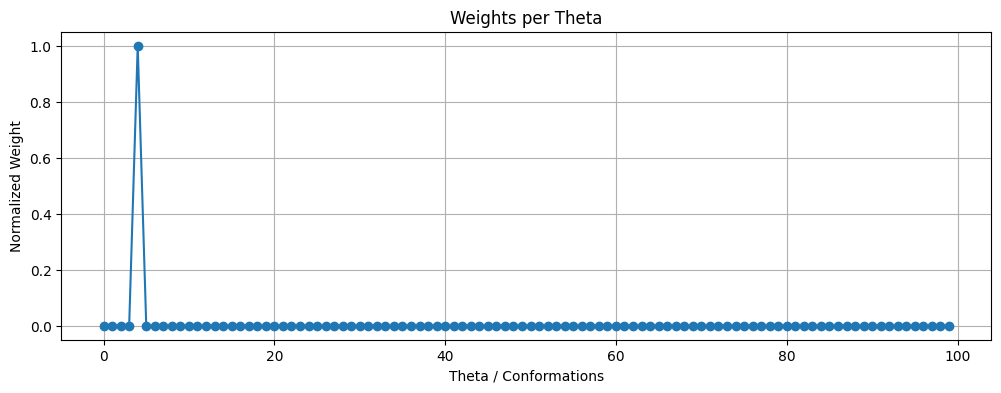

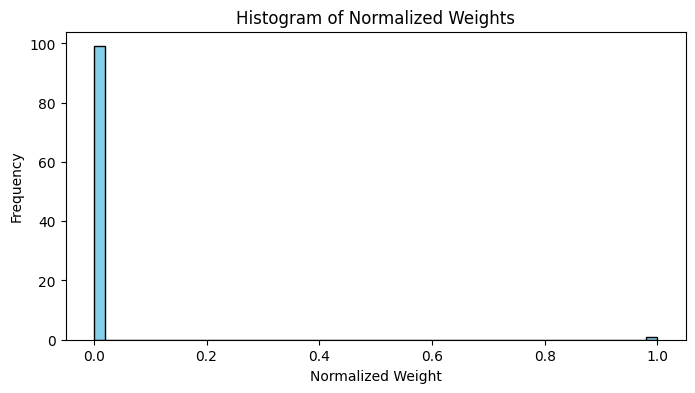

Weights stats:
Mean: 0.01
Std: 0.09949874371066199
Min: 0.0
Max: 1.0


In [50]:
plt.figure(figsize=(12, 6))
plt.imshow(log_prob_matrix_d, aspect='auto', cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.xlabel("Images")
plt.ylabel("Theta / Conformations")
plt.title("Log-Likelihood Matrix")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(log_prob_matrix_d[:100,:100], aspect='auto', cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.xlabel("Images")
plt.ylabel("Theta / Conformations")
plt.title("Log-Likelihood Matrix")
plt.show()

    
    
plt.figure(figsize=(12, 4))
plt.plot(x_opt, marker='o')
plt.xlabel("Theta / Conformations")
plt.ylabel("Normalized Weight")
plt.title("Weights per Theta")
plt.grid(True)
plt.show()
    
    
plt.figure(figsize=(8,4))
plt.hist(x_opt.flatten(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Normalized Weight")
plt.ylabel("Frequency")
plt.title("Histogram of Normalized Weights")
plt.show()
    
    
print("Weights stats:")
print("Mean:", x_opt.mean())
print("Std:", x_opt.std())
print("Min:", x_opt.min())
print("Max:", x_opt.max())

In [ ]:
# log_prob_matrix_d is your likelihood matrix [num_theta, num_images]
# Example: log_prob_matrix_d.shape == (100, 5000)

# Pick an image to visualize
image_idx = 0  # first image
log_probs_for_image = log_prob_matrix_d[:, image_idx]

# Convert log-prob to probability for nicer visualization
probs_for_image = np.exp(log_probs_for_image - np.max(log_probs_for_image))

# Normalize to sum to 1
probs_for_image /= probs_for_image.sum()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(probs_for_image, marker='o')
plt.xlabel("Theta index")
plt.ylabel("Probability")
plt.title(f"Likelihood distribution over θ for image {image_idx}")
plt.grid(True)
plt.show()

In [ ]:
# log_prob_matrix_d is your likelihood matrix [num_theta, num_images]
# Example: log_prob_matrix_d.shape == (100, 5000)

# Pick an image to visualize
image_idx = 2200  # first image
log_probs_for_image = log_prob_matrix_d[:, image_idx]

# Convert log-prob to probability for nicer visualization
probs_for_image = np.exp(log_probs_for_image - np.max(log_probs_for_image))

# Normalize to sum to 1
probs_for_image /= probs_for_image.sum()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(probs_for_image, marker='o')
plt.xlabel("Theta index")
plt.ylabel("Probability")
plt.title(f"Likelihood distribution over θ for image {image_idx}")
plt.grid(True)
plt.show()